In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
weather_data = pd.read_csv("updated_weather_data2.csv")
weather_data["Date & Time"] = pd.to_datetime(weather_data["Date & Time"])
weather_data.set_index("Date & Time", inplace=True, drop=True)
weather_data.head(2)

,Air Temperature [°C],Dew Point [°C],Sea Level Pressure [HPa],Wind Direction [°],Wind Speed [m/s],Sky Condition & Coverage Code,Precipitation (1h) [mm],Precipitation (6h) [mm]
Date & Time,,,,,,,,
2020-01-01 01:00:00,6.7,2.2,1002.8,200.0,3.6,NaN,0.0,NaN
2020-01-01 02:00:00,6.1,1.7,1003.5,280.0,6.2,NaN,0.5,NaN


Figure(640x480)
Axes(0.125,0.11;0.775x0.77)


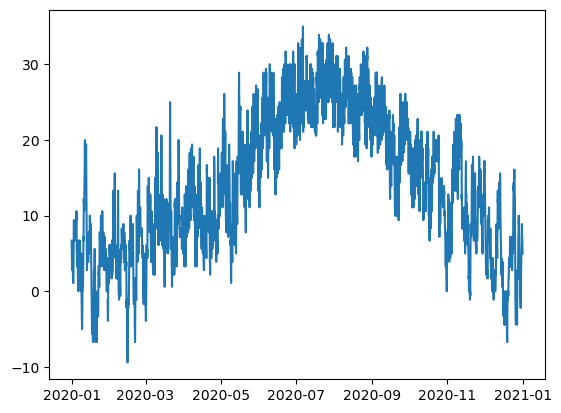

In [3]:
plt.plot(weather_data["Air Temperature [°C]"])

print(plt.gcf())
print(plt.gca())

plt.show()

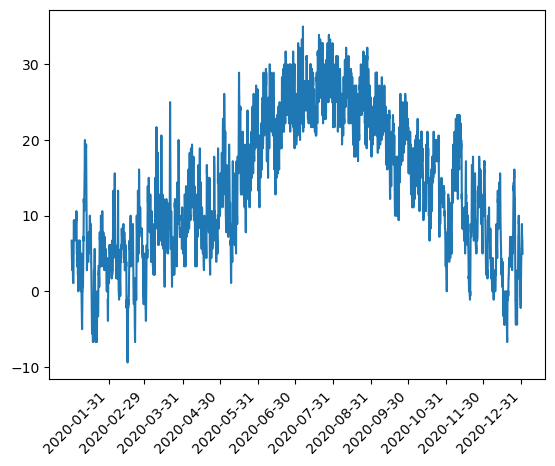

In [4]:
plt.plot(weather_data["Air Temperature [°C]"])

time_frequency = pd.date_range(
    start = weather_data.index.min(),
    end = weather_data.index.max(),
    freq = pd.offsets.MonthEnd()
)
plt.xticks(time_frequency, rotation=45, ha="right")

plt.show()

In [5]:
rolling = weather_data["Air Temperature [°C]"].rolling(window = pd.Timedelta(days = 7))
print(type(rolling))
print(type(rolling.mean()))

<class 'pandas.api.typing.Rolling'>
<class 'pandas.Series'>


In [6]:
rolling.mean().head()

Date & Time
2020-01-01 01:00:00    6.700
2020-01-01 02:00:00    6.400
2020-01-01 03:00:00    6.300
2020-01-01 04:00:00    6.125
2020-01-01 05:00:00    5.900
Name: Air Temperature [°C], dtype: float64

In [7]:
weather_data["Air Temperature [°C]"].head()

Date & Time
2020-01-01 01:00:00    6.7
2020-01-01 02:00:00    6.1
2020-01-01 03:00:00    6.1
2020-01-01 04:00:00    5.6
2020-01-01 05:00:00    5.0
Name: Air Temperature [°C], dtype: float64

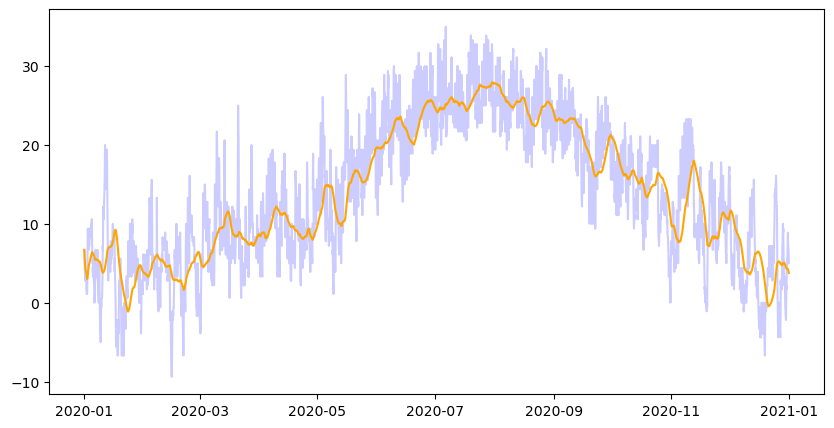

In [8]:
plt.figure(figsize=(10,5))
rolling = weather_data["Air Temperature [°C]"].rolling(window = pd.Timedelta(days = 7))
plt.plot(weather_data["Air Temperature [°C]"], color="blue", alpha=0.2)
plt.plot(rolling.mean(), color="orange")


plt.show()


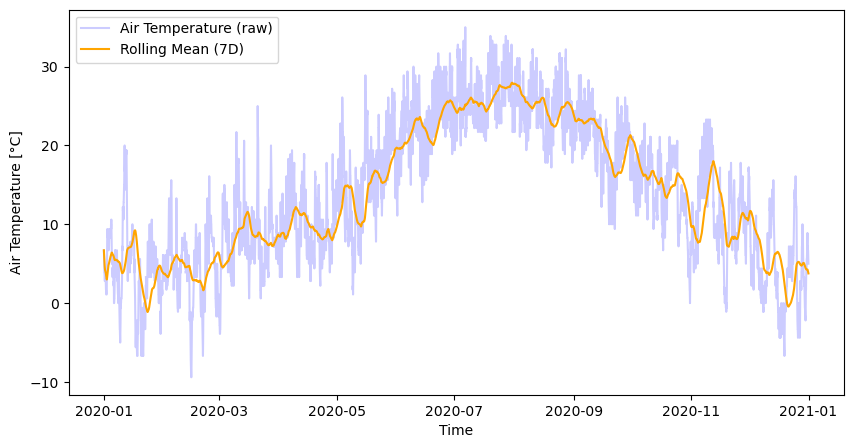

In [9]:
fig, ax = plt.subplots(figsize=(10,5))


rolling = weather_data["Air Temperature [°C]"].rolling(window = pd.Timedelta(days = 7))
ax.plot(weather_data["Air Temperature [°C]"], color="blue", alpha=0.2, label="Air Temperature (raw)")
ax.plot(rolling.mean(), color="orange", label="Rolling Mean (7D)")
ax.set_xlabel("Time")
ax.set_ylabel("Air Temperature [°C]")
ax.legend(loc = "upper left")

plt.show()


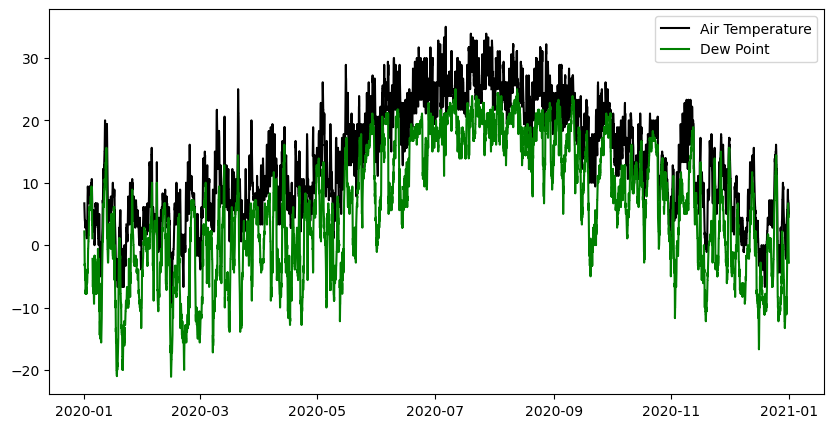

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(weather_data["Air Temperature [°C]"], label="Air Temperature", color="black")
ax.plot(weather_data["Dew Point [°C]"], label="Dew Point", color="green")
ax.legend()
plt.show()

In [11]:
weather_data.head(2)

,Air Temperature [°C],Dew Point [°C],Sea Level Pressure [HPa],Wind Direction [°],Wind Speed [m/s],Sky Condition & Coverage Code,Precipitation (1h) [mm],Precipitation (6h) [mm]
Date & Time,,,,,,,,
2020-01-01 01:00:00,6.7,2.2,1002.8,200.0,3.6,NaN,0.0,NaN
2020-01-01 02:00:00,6.1,1.7,1003.5,280.0,6.2,NaN,0.5,NaN


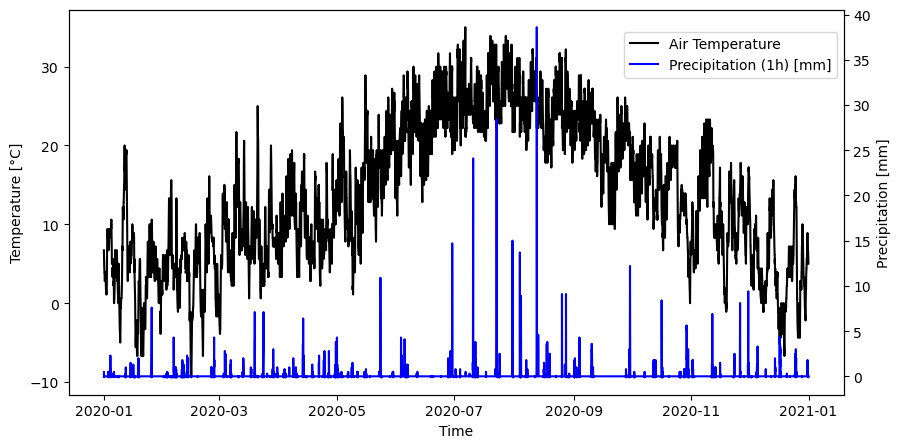

In [12]:
fig, ax1 = plt.subplots(figsize = (10,5))
ax1.plot(weather_data["Air Temperature [°C]"], label="Air Temperature", color="black")
ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature [°C]")

ax2 = ax1.twinx()
ax2.plot(weather_data["Precipitation (1h) [mm]"], label="Precipitation (1h) [mm]", color="blue")
ax2.set_ylabel("Precipitation [mm]")

fig.legend(loc = "upper right", bbox_to_anchor = (0.9, 0.85))

plt.show()

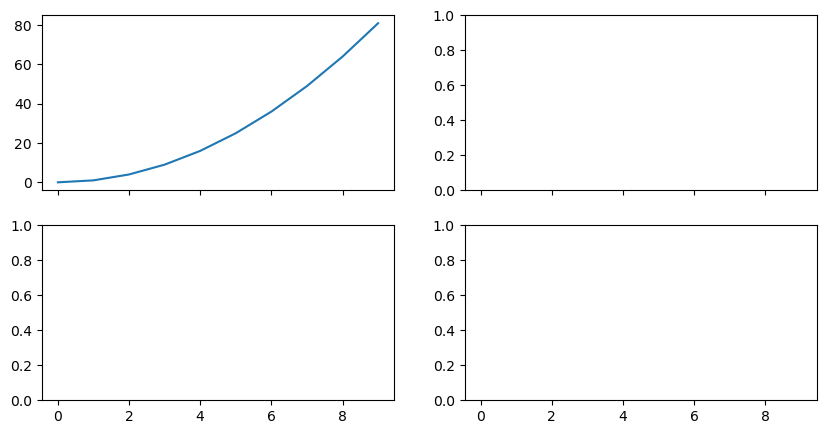

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(10, 5), sharex = True) # figsize is in inches
upper_left_ax = axs[0, 0]
upper_left_ax.plot(range(10), [x**2 for x in range(10)])

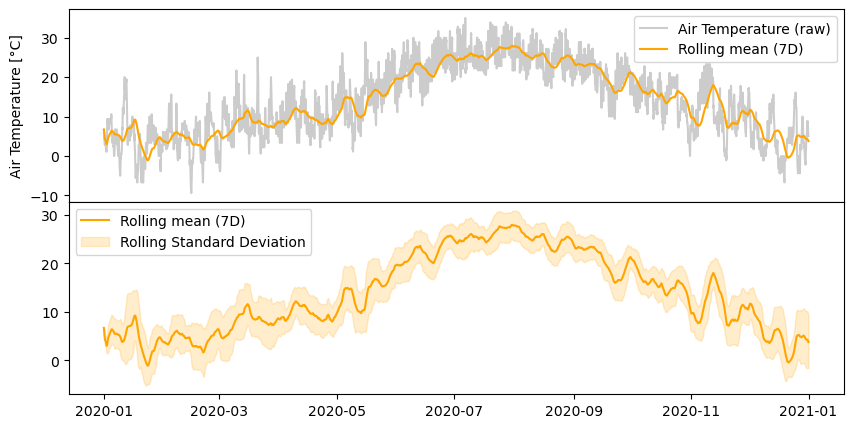

In [14]:
rolling = weather_data["Air Temperature [°C]"].rolling(window=pd.Timedelta(days=7))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,5), sharex=True)
ax1.plot(weather_data["Air Temperature [°C]"], label="Air Temperature (raw)", color="black", alpha=0.2)
ax1.plot(rolling.mean(), label="Rolling mean (7D)", color="orange")
ax1.set_ylabel("Air Temperature [°C]")
ax1.xaxis.set_visible(False)

ax2.plot(rolling.mean(), label="Rolling mean (7D)", color="orange")
ax2.fill_between(
    x = rolling.mean().index,
    y1 = rolling.mean() - rolling.std(),
    y2 = rolling.mean() + rolling.std(),
    color="orange",
    alpha=0.2,
    label = "Rolling Standard Deviation"
)

fig.subplots_adjust(hspace=0)
ax1.legend()
ax2.legend()


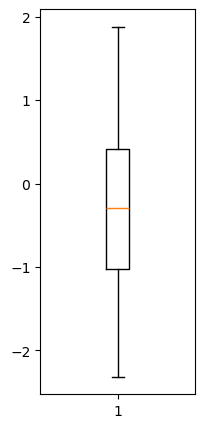

In [15]:
import numpy as np
fig, ax = plt.subplots(figsize = (2,5))

random_data = np.random.normal(loc = 0.0, scale = 1.0, size=100)

ax.boxplot(random_data)


plt.show()


In [16]:
weather_data["Wind Speed [m/s]"].hasnans

True

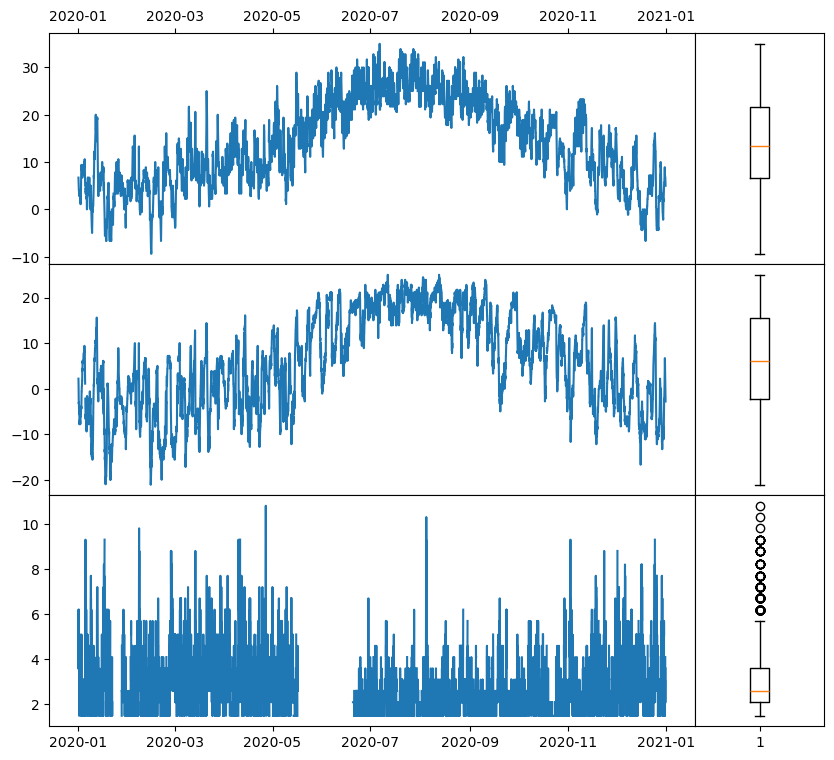

In [17]:
# gridspec: underlying structure that describes what a subplots figure looks like
from matplotlib.gridspec import GridSpec # just for show: please always move imports to the top

to_plot = ["Air Temperature [°C]", "Dew Point [°C]", "Wind Speed [m/s]"]
gs = GridSpec(len(to_plot), 2, width_ratios=[5,1], wspace = 0.0, hspace=0.0)
fig = plt.figure(figsize=(10, 3 * len(to_plot)))

for i, col in enumerate(to_plot) :
    ax_timeseries = plt.subplot(gs[i, 0])
    ax_box = plt.subplot(gs[i, 1])

    ax_timeseries.plot(weather_data[col])
    ax_box.boxplot(weather_data[col].dropna())
    ax_box.set_yticks([])
    if i == 0 :
        ax_timeseries.get_xaxis().set_label_position("top")
        ax_timeseries.get_xaxis().tick_top()
    



# Exercise

In [18]:
waterlevels = pd.read_csv("water_levels.csv", names = ["time", "level"])
waterlevels["time"] = pd.to_datetime(waterlevels["time"])
waterlevels.sort_values("time", inplace=True)
waterlevels.set_index("time", inplace=True, drop=True)
waterlevels.head()

,level
time,
2024-05-04 00:15:00,100
2024-05-04 00:30:00,100
2024-05-04 00:45:00,100
2024-05-04 01:00:00,100
2024-05-04 01:15:00,100


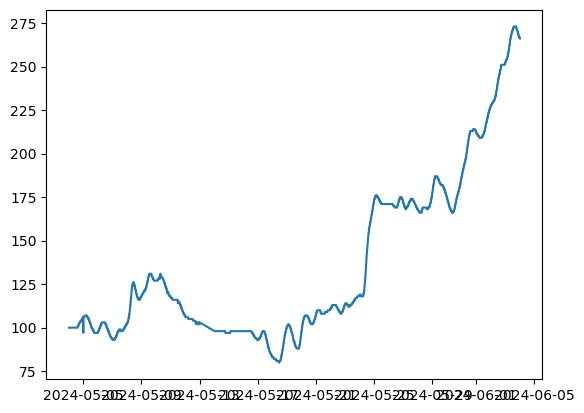

In [19]:
plt.plot(waterlevels["level"])

In [20]:
waterlevels["level"] > 100

time
2024-05-04 00:15:00    False
2024-05-04 00:30:00    False
2024-05-04 00:45:00    False
2024-05-04 01:00:00    False
2024-05-04 01:15:00    False
                       ...  
2024-06-03 23:00:00     True
2024-06-03 23:15:00     True
2024-06-03 23:30:00     True
2024-06-03 23:45:00     True
2024-06-04 00:00:00     True
Name: level, Length: 2880, dtype: bool

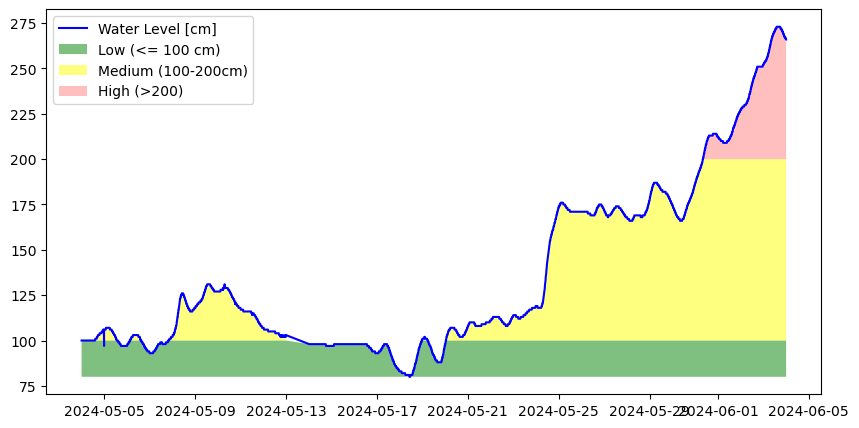

In [21]:
fig, ax = plt.subplots(figsize = (10,5))

x = waterlevels.index
y = waterlevels["level"]

ax.plot(x, y, label="Water Level [cm]", color="blue")

ax.fill_between(x, y.min(), y.clip(upper = 100),
                color="green", alpha = 0.5, label = "Low (<= 100 cm)", edgecolor=None)
ax.fill_between(x, 100, y.clip(upper = 200), where = y > 100,
                color="yellow", alpha = 0.5, label = "Medium (100-200cm)", edgecolor=None)
ax.fill_between(x, 200, y.clip(lower=200), where = y > 200,
                label = "High (>200)", color="red", alpha=0.25, edgecolor=None)


ax.legend()
plt.show()

In [22]:
events = [
    {
        "date": "2024-05-07",
        "time": "08:19",
        "enddate": "2024-05-10",
        "endtime": "05:14",
        "description": "Rainfall Period"
    },
    {
        "date": "2024-05-23",
        "time": "07:00",
        "enddate": "2024-06-04",
        "endtime": "02:00",
        "description": "Rainfall Period"
    },
    {
        "date": "2024-05-24",
        "time": "05:26",
        "enddate": None,
        "endtime": None,
        "description": "Inflow from lake"
    },
    {
        "date": "2024-05-29",
        "time": "19:30",
        "enddate": None,
        "endtime": None,
        "description": "Outflow onto field"
    },
    {
        "date": "2024-05-10",
        "time": "10:07",
        "enddate": "2024-05-18",
        "endtime": "10:52",
        "description": "Dry Period"
    }
]

In [23]:
events[0]['date'] + " " + events[0]['time']
type(waterlevels.index[0])

pandas.Timestamp

(Timestamp('2024-05-08 18:46:30'), 75)


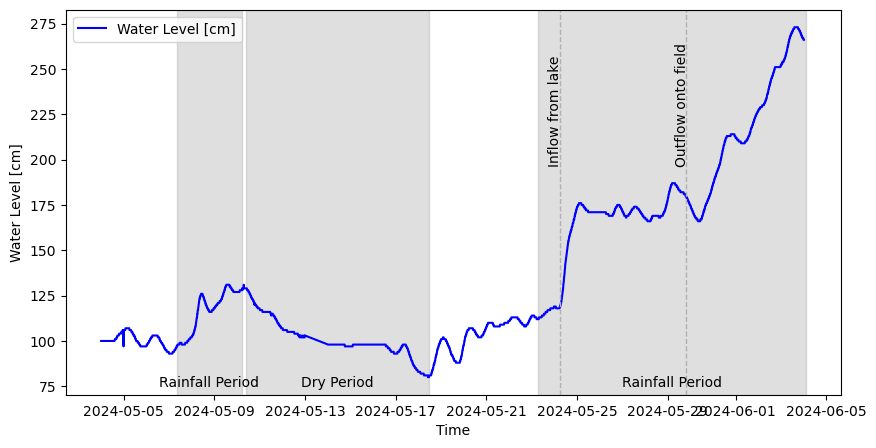

In [40]:
fig, ax = plt.subplots(figsize = (10,5))

x = waterlevels.index
y = waterlevels["level"]
ax.set_xlabel("Time")
ax.set_ylabel("Water Level [cm]")
#ax.set_title("Water Levels with Events")
ax.plot(x, y, label="Water Level [cm]", color="blue")
ymin, ymax = ax.get_ylim()

texts = []

for entry in events :
    start = pd.to_datetime(entry["date"] + " " + entry["time"])
    end = entry["enddate"]
    if end : # we have an end time --> we have a range
        end = pd.to_datetime(entry["enddate"] + " " + entry["endtime"])
        ax.axvspan(start, end, color="gray", alpha = 0.25)
        texts.append(ax.annotate(text = entry["description"],
                    xy = (start + 0.5*(end - start), 75),
                    horizontalalignment="center"
                   ))
    else : # no end time --> just a singular event
        ax.axvline(start, linestyle="--", linewidth=1, color=plt.rcParams["grid.color"])
        texts.append(ax.annotate(text = entry["description"], # text content
                    xy = (start - pd.Timedelta(hours = 12), ymin + 0.6 * (ymax-ymin)),           # position parameter
                    rotation = 90,
        ))


example_text = texts[0]
print(example_text.get_position())

ax.legend()

#fig.tight_layout()

plt.show()


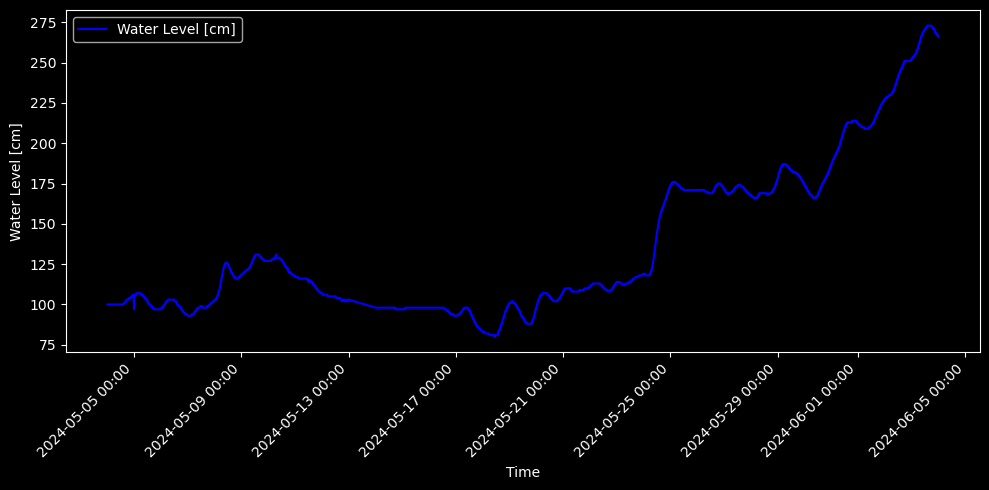

In [35]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize = (10,5))
x = waterlevels.index
y = waterlevels["level"]
ax.set_xlabel("Time")
ax.set_ylabel("Water Level [cm]")
#ax.set_title("Water Levels with Events")
ax.plot(x, y, label="Water Level [cm]", color="blue")
ymin, ymax = ax.get_ylim()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
fig.autofmt_xdate(rotation=45)
fig.tight_layout()
ax.legend()
plt.show()

In [38]:
plt.style.available
plt.style.use("default")

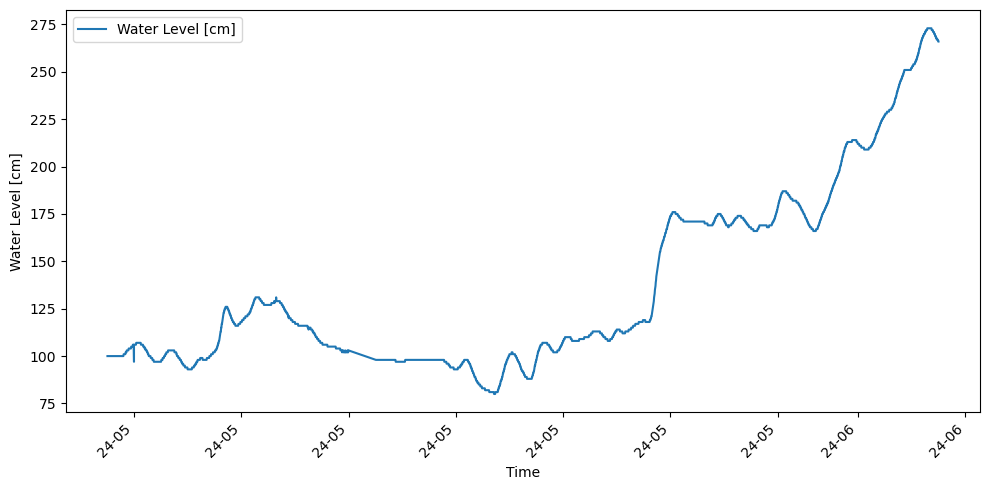

In [39]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(figsize = (10,5))
x = waterlevels.index
y = waterlevels["level"]
ax.set_xlabel("Time")
ax.set_ylabel("Water Level [cm]")
#ax.set_title("Water Levels with Events")
ax.plot(x, y, label="Water Level [cm]")
ymin, ymax = ax.get_ylim()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%y-%m"))
fig.autofmt_xdate(rotation=45)
fig.tight_layout()
ax.legend()
plt.show()

In [26]:
a = 0,
type(a)

tuple

In [42]:
plt.rcParamsDefault

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   